# RL选择最优策略和动作的几种方法

## 贪心算法

In [ ]:
import numpy as np

class EpsilonGreedy:
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon # 探索概率
        self.q = np.zeros(n_arms)         # 每个摇臂的估计期望
        self.n = np.zeros(n_arms)         # 每个摇臂被拉过的次数

    def select(self):
        # 如果选中探索，那么就随机选择一个摇臂，否则就选择当前估计期望最大的摇臂
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)   # 探索
        return np.argmax(self.q)                     # 利用

    def update(self, arm, reward):
        self.n[arm] += 1
        # 增量更新：新印象 = 老印象 + (实际体验 - 老印象) × 权重 
        self.q[arm] += (reward - self.q[arm]) / self.n[arm]

# 遗憾值logT级别的算法

遗憾界（Regret Bound）
1. 定义：假设你开了天眼，每次都选了实际收益最高的那个摇臂（最优解）。现实中你用了某个算法，没能每次都选对。这中间“少赚的差价”，就是你的“遗憾（Regret）”
2. 多少遗憾值最好：只要你还在探索（还在试错），你的遗憾总值就一定会随着时间不断增加。科学家证明了一个数学极限（Lai-Robbins 下界）：任何聪明的算法，它的遗憾值增长速度，最慢最慢也得是对数级别的增长（$\log T$）。上一节学的 
   
UCB 和 Thompson 采样之所以能在工业界封神，就是因为数学家证明了：它们的遗憾增长速度就是 $\log T$，已经触碰到了理论的极限，达到了“渐进最优”。

## UCB

核心逻辑：我们在选择摇臂时，不仅看它目前的“平均收益”，还要加上一个“不确定性奖金”。如果一个摇臂我们拉得很少，它的不确定性就很大，算法会给予它高额的探索奖金，鼓励你去试一试。

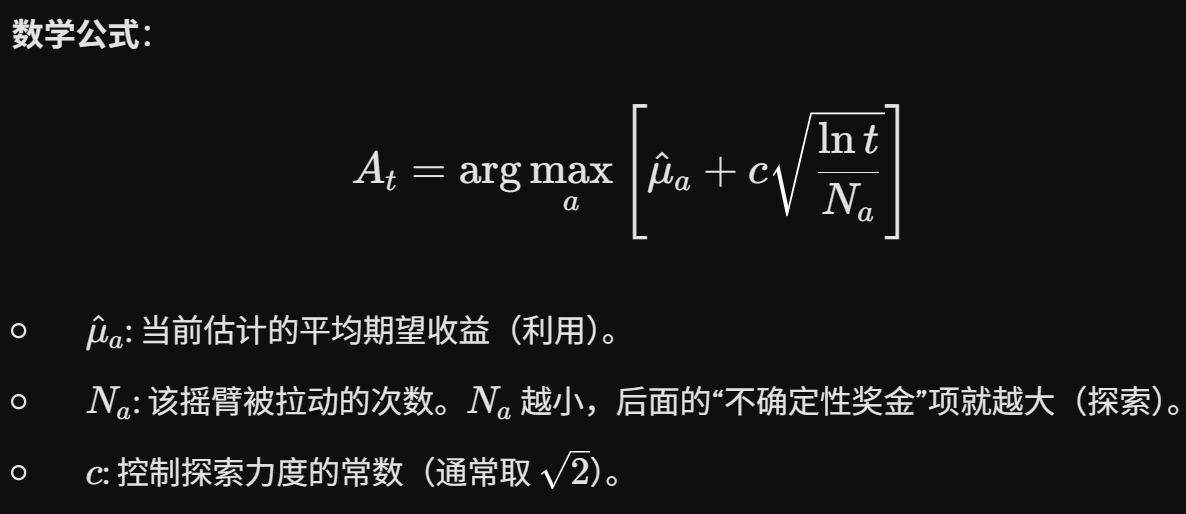


In [ ]:
class UCB1:
    def __init__(self, n_arms, c=1.0):
        self.n_arms = n_arms
        self.c = c # 探索常数，探索常数越大，它探索的可能性就越大
        self.q = np.zeros(n_arms) # 估计期望
        self.n = np.zeros(n_arms) # 摆臂被拉过的次数
        self.t = 0 # 探索常数， self.t 不断变大，会在系统中产生一种“随时间推移，不断逼迫算法去探索冷门摇臂”的动态平衡机制

    def select(self):
        self.t += 1
        # 第一次：每个摇臂都试一遍，避免除零
        for arm in range(self.n_arms):
            if self.n[arm] == 0:
                return arm
        # 关键代码 ： 估计期望 + 探索项（探索常数*np.log(self.t) / self.n）
        ucb = self.q + self.c * np.sqrt(np.log(self.t) / self.n)
        return np.argmax(ucb)

    def update(self, arm, reward):
        self.n[arm] += 1
        self.q[arm] += (reward - self.q[arm]) / self.n[arm] 

## Thompson 采样的贝叶斯视角

alpha 是赢的次数，beta是输的次数，根据alpha和beta的一个情况来决定抽出来的结果是什么：
1. 看“胜率比例”决定纸条的中心（决定平均收益）
   1. 箱子里最多的纸条，永远聚集在目前的“历史胜率”附近。
   2. 如果你输入的是 beta(90, 10)（90赢，10输，胜率 90%），那箱子里写着 0.9 附近的纸条就最多。
   3. 如果你输入的是 beta(10, 90)（10赢，90输，胜率 10%），那箱子里写着 0.1 附近的纸条就最多。
2. 看“总测试次数”决定纸条的杂乱程度
   1. 总数少时（比如 beta(1, 1)）： 虽然历史胜率是 50%，但因为你一共才试了 2 次，系统觉得“一切皆有可能”。所以箱子里的纸条是从 0.1 到 0.9 均匀混杂的。你伸手一摸，摸到 0.1 还是 0.9，全看命。这就是给未知事物的高“容错率”。
   2. 总数多时（比如 beta(500, 500)）： 历史胜率依然是 50%，但因为你试了整整 1000 次！系统已经极其确信它就是个半吊子。此时，系统会把箱子里 0.1、0.9 这种极端的纸条全部扔掉，只留下 0.49 到 0.51 的纸条。你再怎么摸，摸出来的数字也被死死锁在 0.5 左右，绝对不可能再爆冷了。

总结 ： 
1. 抽的数据的分布永远在历史胜率附近
2. 抽的数据的次数决定了数据的凌乱程度， 历史抽取次数越多，抽取的数据的范围越窄

In [ ]:
class ThompsonSampling:
    def __init__(self, n_arms, alpha=1, beta=1):
        self.n_arms = n_arms
        self.alpha = np.full(n_arms, alpha, dtype=float)
        self.beta = np.full(n_arms, beta, dtype=float)

    def select(self):
        # 核心代码 ： 从历史战绩中抽取当前使用的摇臂
        samples = np.random.beta(self.alpha, self.beta)
        return np.argmax(samples)

    def update(self, arm, reward):
        # reward 假设是 0/1
        if reward > 0.5:
            self.alpha[arm] += 1
        else:
            self.beta[arm] += 1